In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.getcwd()

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Data Loading

In [3]:
df = pd.read_excel("FinTech_ChainAudit.xlsx")

In [5]:
df.head()

,Transaction_ID,Date,Wallet_Type,Tran_Type,Blockchain,Amount,Gas_Fee_USD,Customer_Type,Region,Processing_Time_sec,Fraud_Risk_Score,Compliance_Status,Marketing_Campaign,Number_of_Active_Customers,Daily_Revenue_USD,Sales
0,TXN100002,2025-07-22,Customer,Swap,BSC,20555.75,32.61,VIP,America,203.0,38.98,Pass,Yes,929.0,12870.12,24666.9
1,TXN100003,2025-12-27,NaN,Staking,Solana,25571.60,16.49,Institutional,Europe,152.0,56.57,Pass,No,519.0,5099.70,30685.92
2,TXN100004,2025-07-27,Operational,DeFi,Polygon,40219.77,39.93,Retail,Europe,27.0,82.62,Review,Yes,2002.0,22341.17,48263.724
3,TXN100005,2025-08-27,Customer,saving,Polygon,44989.59,18.03,VIP,Europe,177.0,1.05,Pass,No,3205.0,31676.08,-5000
4,TXN100006,2025-12-16,Treasury,DeFi,Solana,NaN,77.33,Institutional,Middle East,202.0,29.83,Review,No,3439.0,24182.19,NaN


In [6]:
df.tail()

,Transaction_ID,Date,Wallet_Type,Tran_Type,Blockchain,Amount,Gas_Fee_USD,Customer_Type,Region,Processing_Time_sec,Fraud_Risk_Score,Compliance_Status,Marketing_Campaign,Number_of_Active_Customers,Daily_Revenue_USD,Sales
1996,TXN101998,2025-02-20,Employee,Staking,Polygon,29301.51,92.99,Retail,America,181.0,94.83,Fail,No,820.0,3953.46,35161.812
1997,TXN101999,2025-02-21,Employee,DeFi,Ethereum,42861.13,44.11,VIP,Middle East,222.0,39.01,Review,No,4650.0,36834.23,51433.356
1998,TXN102000,2025-08-14,Customer,NFT,Solana,33225.74,82.92,Retail,Asia,67.0,61.01,Fail,Yes,1856.0,26083.71,39870.888
1999,TXN102001,2025-09-11,Employee,NFT,Polygon,30977.11,100.98,VIP,America,255.0,73.39,Pass,No,2633.0,23772.50,37172.532
2000,TXN100002,2025-07-22,Customer,Swap,BSC,20555.75,32.61,VIP,America,203.0,38.98,Pass,Yes,929.0,12870.12,24666.9


## Data Understanding

In [8]:
df.shape

(2001, 16)

In [9]:
df.columns

Index(['Transaction_ID', 'Date', 'Wallet_Type', 'Tran_Type', 'Blockchain',
       'Amount ', 'Gas_Fee_USD', 'Customer_Type', 'Region',
       'Processing_Time_sec', 'Fraud_Risk_Score', 'Compliance_Status',
       'Marketing_Campaign', 'Number_of_Active_Customers', 'Daily_Revenue_USD',
       'Sales'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Transaction_ID              1996 non-null   object 
 1   Date                        1982 non-null   object 
 2   Wallet_Type                 1922 non-null   object 
 3   Tran_Type                   1975 non-null   object 
 4   Blockchain                  1983 non-null   object 
 5   Amount                      1990 non-null   float64
 6   Gas_Fee_USD                 1975 non-null   float64
 7   Customer_Type               1981 non-null   object 
 8   Region                      1974 non-null   object 
 9   Processing_Time_sec         1989 non-null   float64
 10  Fraud_Risk_Score            1986 non-null   float64
 11  Compliance_Status           1972 non-null   object 
 12  Marketing_Campaign          1992 non-null   object 
 13  Number_of_Active_Customers  1981 

In [11]:
df.dtypes

Transaction_ID                 object
Date                           object
Wallet_Type                    object
Tran_Type                      object
Blockchain                     object
Amount                        float64
Gas_Fee_USD                   float64
Customer_Type                  object
Region                         object
Processing_Time_sec           float64
Fraud_Risk_Score              float64
Compliance_Status              object
Marketing_Campaign             object
Number_of_Active_Customers    float64
Daily_Revenue_USD             float64
Sales                          object
dtype: object

In [12]:
df.describe()

,Amount,Gas_Fee_USD,Processing_Time_sec,Fraud_Risk_Score,Number_of_Active_Customers,Daily_Revenue_USD
count,1990.000000,1975.000000,1989.000000,1986.000000,1981.000000,1987.000000
mean,24990.586317,59.411241,153.158371,48.763243,2552.363958,22372.492652
std,14346.120987,35.264629,85.973187,28.973853,1425.366197,10412.518021
min,-15000.000000,0.650000,5.000000,0.060000,51.000000,235.680000
25%,12187.292500,27.960000,79.000000,23.630000,1353.000000,14403.990000
50%,24819.780000,58.970000,154.000000,47.885000,2549.000000,22386.230000
75%,37376.755000,90.200000,226.000000,73.217500,3780.000000,30141.950000
max,49979.940000,119.970000,300.000000,99.900000,6676.000000,50623.470000


In [13]:
df.describe(include="all")

,Transaction_ID,Date,Wallet_Type,Tran_Type,Blockchain,Amount,Gas_Fee_USD,Customer_Type,Region,Processing_Time_sec,Fraud_Risk_Score,Compliance_Status,Marketing_Campaign,Number_of_Active_Customers,Daily_Revenue_USD,Sales
count,1996,1982,1922,1975,1983,1990.000000,1975.000000,1981,1974,1989.000000,1986.000000,1972,1992,1981.000000,1987.000000,1991.0
unique,1995,365,5,8,4,NaN,NaN,3,4,NaN,NaN,3,2,NaN,NaN,1988.0
top,TXN100002,2025-03-06,Employee,Swap,BSC,NaN,NaN,VIP,America,NaN,NaN,Pass,Yes,NaN,NaN,24666.9
freq,2,15,513,307,546,NaN,NaN,675,507,NaN,NaN,665,1002,NaN,NaN,2.0
mean,NaN,NaN,NaN,NaN,NaN,24990.586317,59.411241,NaN,NaN,153.158371,48.763243,NaN,NaN,2552.363958,22372.492652,NaN
std,NaN,NaN,NaN,NaN,NaN,14346.120987,35.264629,NaN,NaN,85.973187,28.973853,NaN,NaN,1425.366197,10412.518021,NaN
min,NaN,NaN,NaN,NaN,NaN,-15000.000000,0.650000,NaN,NaN,5.000000,0.060000,NaN,NaN,51.000000,235.680000,NaN
25%,NaN,NaN,NaN,NaN,NaN,12187.292500,27.960000,NaN,NaN,79.000000,23.630000,NaN,NaN,1353.000000,14403.990000,NaN
50%,NaN,NaN,NaN,NaN,NaN,24819.780000,58.970000,NaN,NaN,154.000000,47.885000,NaN,NaN,2549.000000,22386.230000,NaN
75%,NaN,NaN,NaN,NaN,NaN,37376.755000,90.200000,NaN,NaN,226.000000,73.217500,NaN,NaN,3780.000000,30141.950000,NaN


In [17]:
df["Blockchain"].unique()

array(['BSC', 'Solana', 'Polygon', 'Ethereum', nan], dtype=object)

## Data Cleaning

In [18]:
df.isnull().sum()

Transaction_ID                 5
Date                          19
Wallet_Type                   79
Tran_Type                     26
Blockchain                    18
Amount                        11
Gas_Fee_USD                   26
Customer_Type                 20
Region                        27
Processing_Time_sec           12
Fraud_Risk_Score              15
Compliance_Status             29
Marketing_Campaign             9
Number_of_Active_Customers    20
Daily_Revenue_USD             14
Sales                         10
dtype: int64

In [19]:
(df.isnull().sum() / len(df)) * 100

Transaction_ID                0.249875
Date                          0.949525
Wallet_Type                   3.948026
Tran_Type                     1.299350
Blockchain                    0.899550
Amount                        0.549725
Gas_Fee_USD                   1.299350
Customer_Type                 0.999500
Region                        1.349325
Processing_Time_sec           0.599700
Fraud_Risk_Score              0.749625
Compliance_Status             1.449275
Marketing_Campaign            0.449775
Number_of_Active_Customers    0.999500
Daily_Revenue_USD             0.699650
Sales                         0.499750
dtype: float64

In [22]:
df[df.select_dtypes(include="number").columns] = df.select_dtypes(include="number").fillna(df.select_dtypes(include="number").median())

In [23]:
df[df.select_dtypes(include="object").columns] = df.select_dtypes(include="object").fillna("Unknown")

In [24]:
df.isnull().sum()

Transaction_ID                0
Date                          0
Wallet_Type                   0
Tran_Type                     0
Blockchain                    0
Amount                        0
Gas_Fee_USD                   0
Customer_Type                 0
Region                        0
Processing_Time_sec           0
Fraud_Risk_Score              0
Compliance_Status             0
Marketing_Campaign            0
Number_of_Active_Customers    0
Daily_Revenue_USD             0
Sales                         0
dtype: int64

In [25]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1996    False
1997    False
1998    False
1999    False
2000     True
Length: 2001, dtype: bool

In [14]:
df.duplicated().sum()

0

In [15]:
df[df.duplicated()]


,Transaction_ID,Date,Wallet_Type,Tran_Type,Blockchain,Amount,Gas_Fee_USD,Customer_Type,Region,Processing_Time_sec,Fraud_Risk_Score,Compliance_Status,Marketing_Campaign,Number_of_Active_Customers,Daily_Revenue_USD,Sales


In [13]:
df = df.drop_duplicates()

## Exploratory data Analysis (EDA)

### Histogram

In [18]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

In [19]:
df["Sales"] = df["Sales"].fillna(df["Sales"].median())

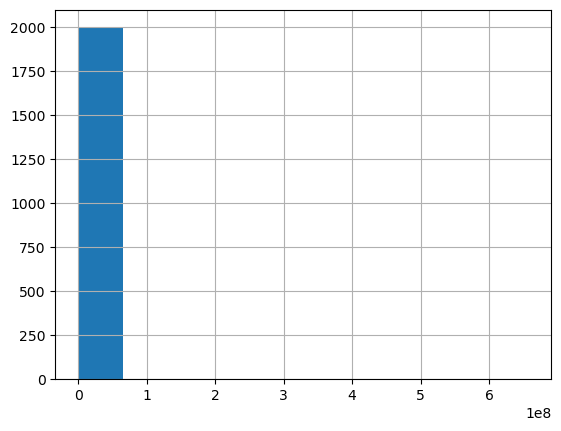

In [20]:
df["Sales"].hist()

plt.show()

In [21]:
df = df.apply(lambda x: pd.to_numeric(x, errors="ignore"))

In [22]:
df[df.select_dtypes(include="number").columns] = df.select_dtypes(include="number").fillna(df.select_dtypes(include="number").median())

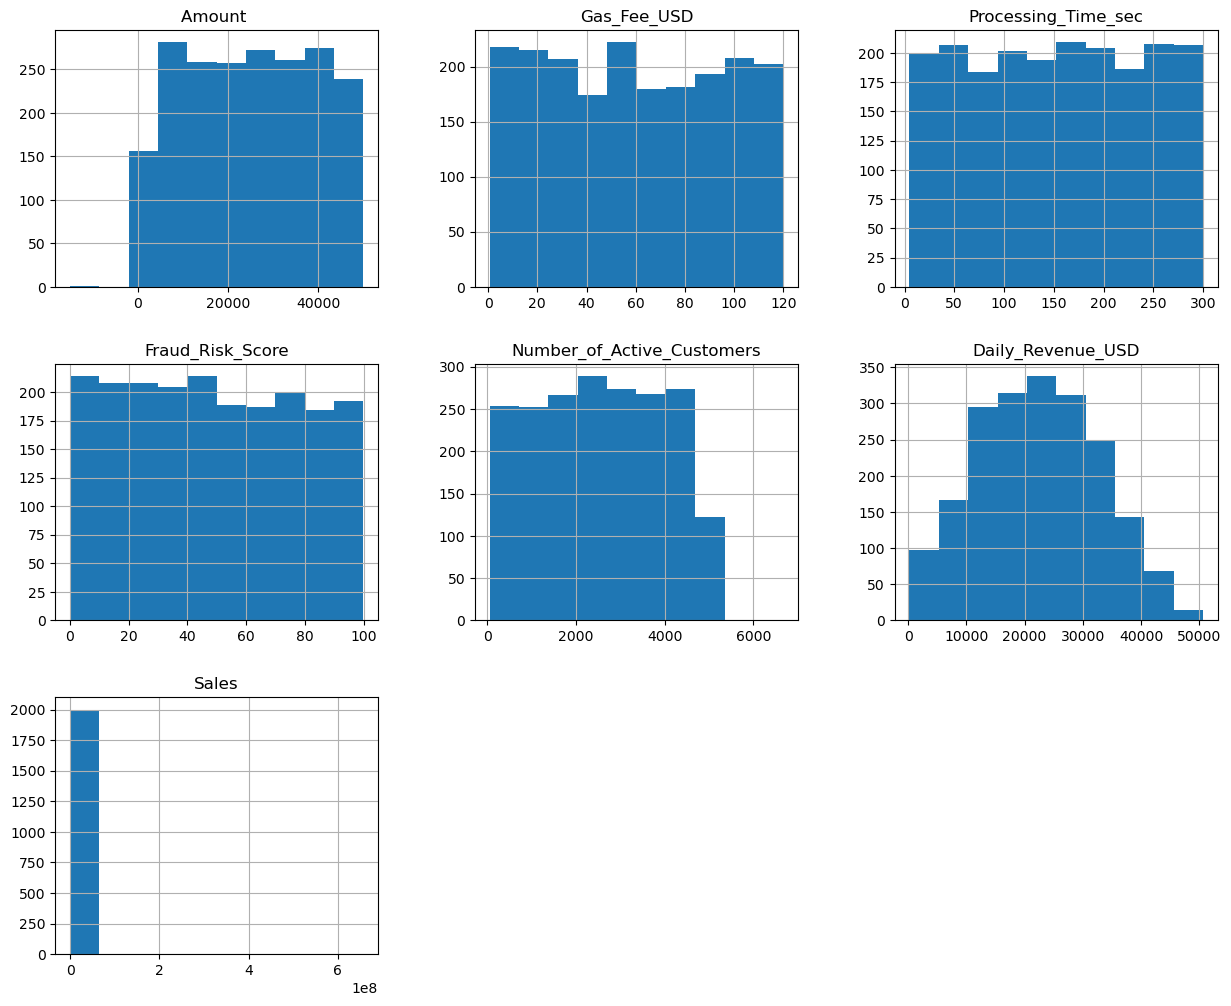

In [23]:
df.select_dtypes(include="number").hist(figsize=(15, 12))
plt.show()

### Distribution Plot

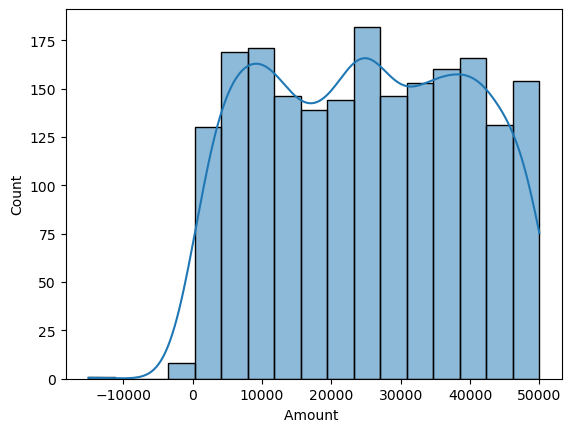

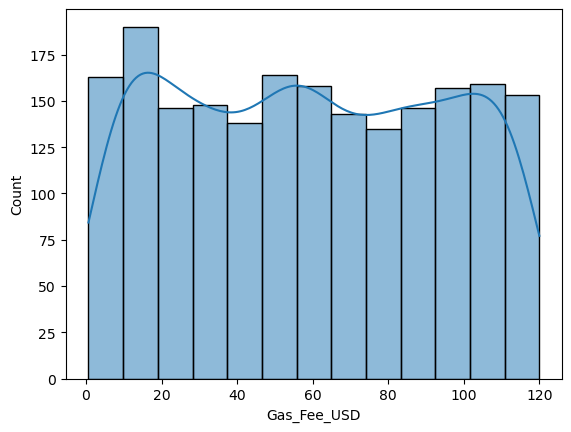

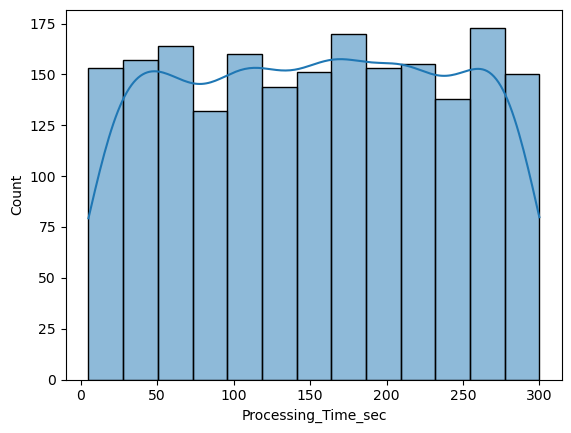

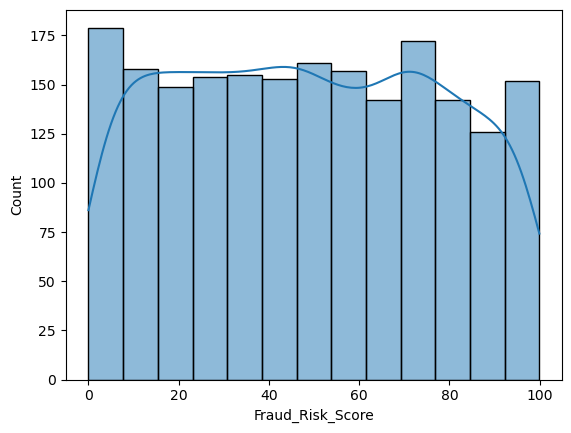

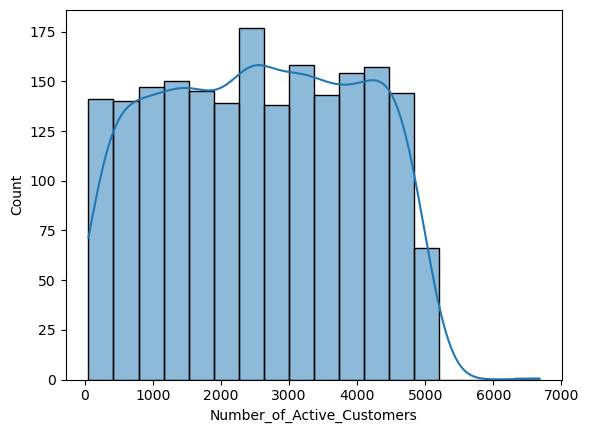

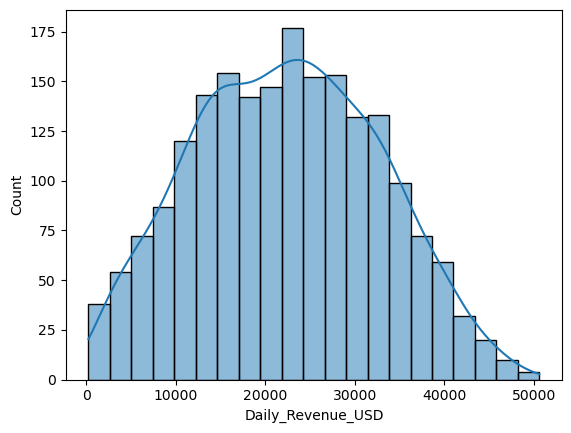

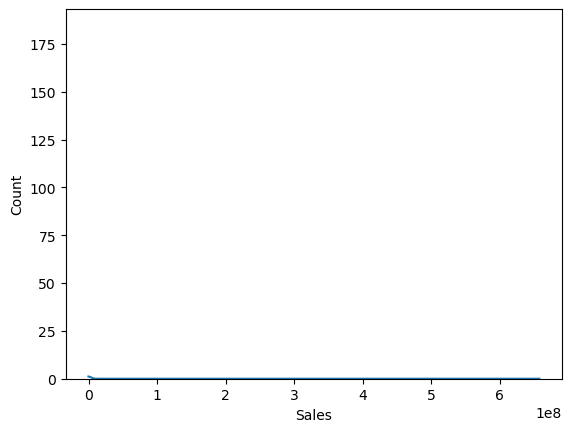

In [24]:
for column in df.select_dtypes(include="number").columns:
    sns.histplot(df[column], kde=True)
    plt.show()

### Bar Chart

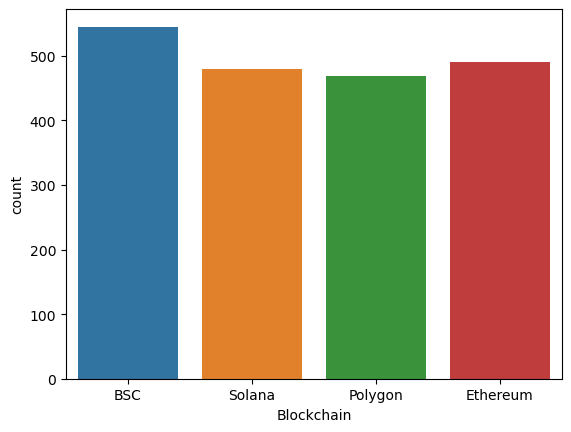

In [25]:
sns.countplot(x="Blockchain", data=df)

plt.show()

### Pie Chart

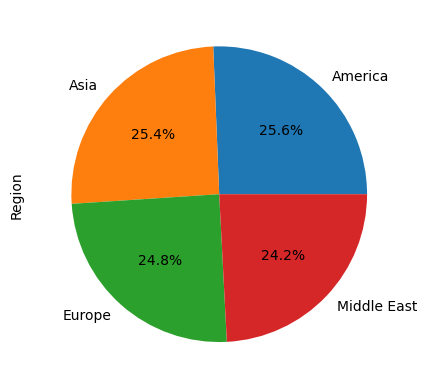

In [28]:
df["Region"].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

### Out Liers

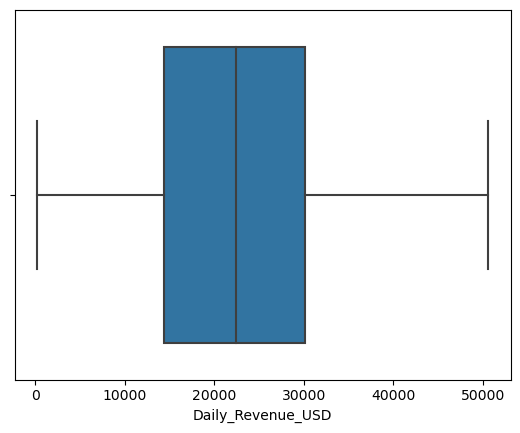

In [29]:
sns.boxplot(x=df["Daily_Revenue_USD"])

plt.show()

### Scatter Plot 

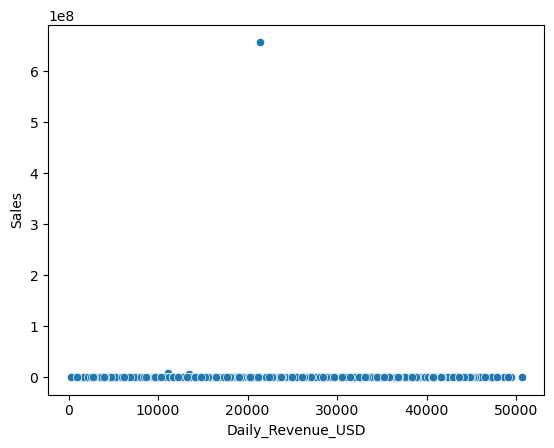

In [30]:
sns.scatterplot(
    x="Daily_Revenue_USD",
    y="Sales",
    data=df
)

plt.show()

### Corelation 

In [32]:
df.select_dtypes(include="number").corr()

,Amount,Gas_Fee_USD,Processing_Time_sec,Fraud_Risk_Score,Number_of_Active_Customers,Daily_Revenue_USD,Sales
Amount,1.000000,0.025036,0.039557,0.023432,0.014220,0.237956,0.014841
Gas_Fee_USD,0.025036,1.000000,-0.013799,-0.013383,-0.020449,-0.073929,-0.021670
Processing_Time_sec,0.039557,-0.013799,1.000000,0.026160,-0.009545,-0.002077,0.017776
Fraud_Risk_Score,0.023432,-0.013383,0.026160,1.000000,0.010137,-0.004570,-0.002608
Number_of_Active_Customers,0.014220,-0.020449,-0.009545,0.010137,1.000000,0.837774,-0.003593
Daily_Revenue_USD,0.237956,-0.073929,-0.002077,-0.004570,0.837774,1.000000,-0.002443
Sales,0.014841,-0.021670,0.017776,-0.002608,-0.003593,-0.002443,1.000000


### Heat Map

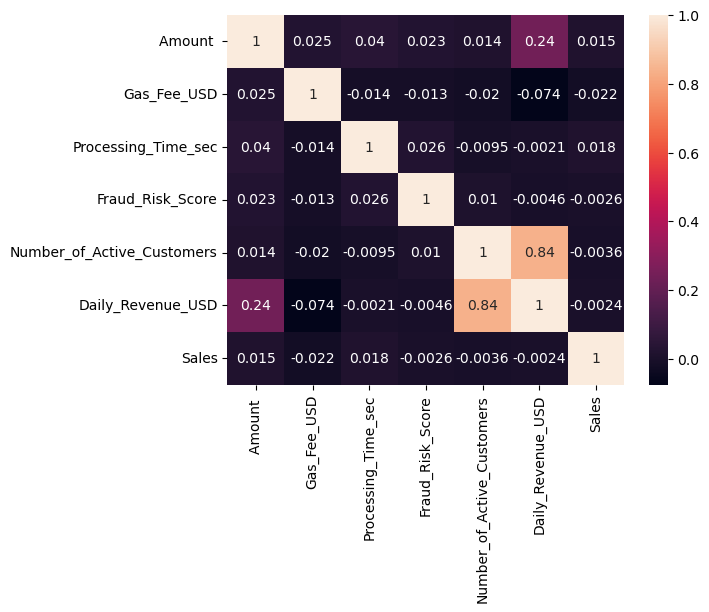

In [33]:
correlation = df.select_dtypes(include="number").corr()

sns.heatmap(correlation, annot=True)

plt.show()


In [34]:
df.columns = df.columns.str.strip()

In [37]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Sales_Category"] = (df["Sales"] > df["Sales"].median()).astype(int)

### Define X and Y variables

In [38]:
X = df[["Amount", "Gas_Fee_USD", "Daily_Revenue_USD"]]

y = df["Sales_Category"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

### Applying Logistics Regression 

In [43]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [44]:
predictions = model.predict(X_test)

In [47]:
accuracy_score(y_test, predictions)

0.8325

In [48]:
confusion_matrix(y_test, predictions)

array([[151,  51],
       [ 16, 182]], dtype=int64)

In [49]:
classification_report(y_test, predictions)

'              precision    recall  f1-score   support\n\n           0       0.90      0.75      0.82       202\n           1       0.78      0.92      0.84       198\n\n    accuracy                           0.83       400\n   macro avg       0.84      0.83      0.83       400\nweighted avg       0.84      0.83      0.83       400\n'

In [51]:
cm = confusion_matrix(y_test, predictions)

pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

,Predicted 0,Predicted 1
Actual 0,151,51
Actual 1,16,182


In [52]:
report = classification_report(y_test, predictions, output_dict=True)

pd.DataFrame(report).transpose()

,precision,recall,f1-score,support
0,0.904192,0.747525,0.818428,202.0000
1,0.781116,0.919192,0.844548,198.0000
accuracy,0.832500,0.832500,0.832500,0.8325
macro avg,0.842654,0.833358,0.831488,400.0000
weighted avg,0.843269,0.832500,0.831357,400.0000


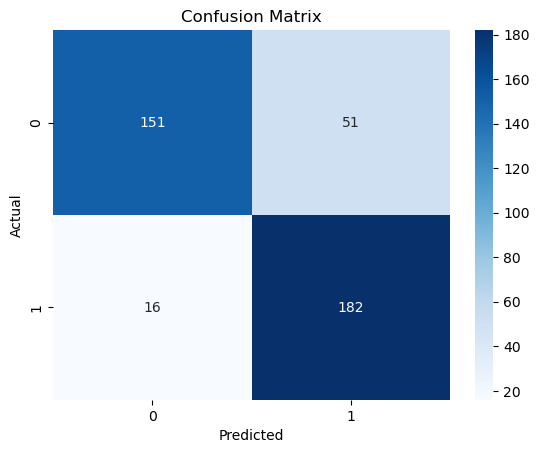

In [54]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [61]:
df.to_excel("New_columns.xlsx", index=False)

In [62]:
import os
print(os.path.abspath("New_columns.xlsx"))

C:\Users\Farmaan\Applying Logistic regression\New_columns.xlsx


In [64]:
import os
os.startfile("New_columns.xlsx")